# Exploratory Data Analysis
## Family Planning Among Married Women of Reproductive Age — Kassala City, Sudan 2025
**N = 384 | Mixed-methods: quantitative (SPSS) + qualitative (thematic analysis)**

This notebook covers data quality, demographic profile, FP use patterns, and preliminary associations before formal SPSS analysis. Qualitative findings from open-ended responses are documented separately in `qualitative_analysis.md`.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

df = pd.read_excel("../1_data/cleaned/cleaned_data.xlsx")
print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"FP use prevalence: {df['fp_use'].mean()*100:.1f}%")


Dataset: 384 rows × 38 columns
FP use prevalence: 46.0%


## 1. Data Quality

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:" if not missing.empty else "No missing values.")
if not missing.empty:
    print(missing.head(10))
print(f"\nAge range: {df['age'].min():.0f}–{df['age'].max():.0f} years (mean {df['age'].mean():.2f} ± {df['age'].std():.2f})")


Columns with missing values:
education                85
education_code           85
husband_reaction         49
husband_reaction_code    49
fp_use                    6
dtype: int64

Age range: 16–45 years (mean 27.53 ± 7.01)


## 2. Demographic Profile

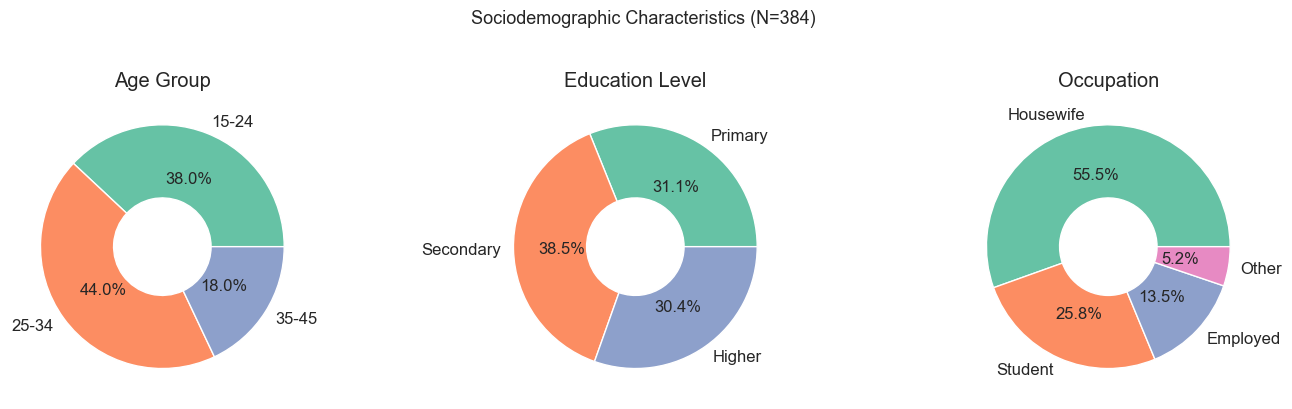

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = sns.color_palette("Set2")

for ax, (col, order, title) in zip(axes, [
    ("age_group", ["15-24", "25-34", "35-45"], "Age Group"),
    ("education", ["None", "Primary", "Secondary", "Higher"], "Education Level"),
    ("occupation", None, "Occupation"),
]):
    counts = df[col].value_counts()
    if order:
        counts = counts.reindex(order).dropna()
    ax.pie(counts, labels=counts.index, autopct="%1.1f%%",
           colors=palette, wedgeprops={"width": 0.6, "edgecolor": "white"})
    ax.set_title(title)
plt.suptitle(f"Sociodemographic Characteristics (N=384)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 3. Family Planning Use and Methods

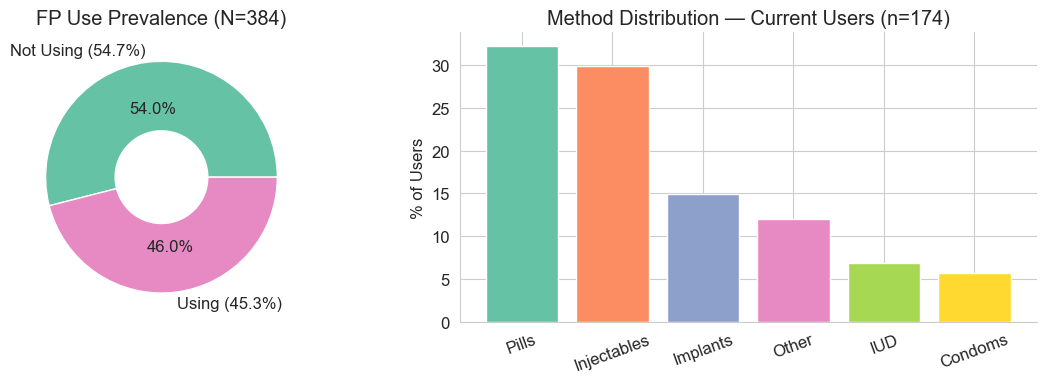

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# FP use
fp_counts = df["fp_use"].map({1: "Using (45.3%)", 0: "Not Using (54.7%)"}).value_counts()
axes[0].pie(fp_counts, labels=fp_counts.index, autopct="%1.1f%%",
            colors=[sns.color_palette("Set2")[0], sns.color_palette("Set2")[3]],
            wedgeprops={"width": 0.6, "edgecolor": "white"})
axes[0].set_title("FP Use Prevalence (N=384)")

# Method distribution among users
method_cols = {
    "method_pills": "Pills", "method_injectables": "Injectables",
    "method_implants": "Implants", "method_other": "Other",
    "method_iud": "IUD", "method_condoms": "Condoms",
}
users = df[df["fp_use"] == 1]
method_pcts = {label: users[col].mean() * 100 for col, label in method_cols.items()}
method_pcts = dict(sorted(method_pcts.items(), key=lambda x: x[1], reverse=True))
axes[1].bar(list(method_pcts.keys()), list(method_pcts.values()),
            color=sns.color_palette("Set2"))
axes[1].set_title(f"Method Distribution — Current Users (n={len(users)})")
axes[1].set_ylabel("% of Users")
axes[1].tick_params(axis="x", rotation=20)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## 4. Spousal and Community Factors

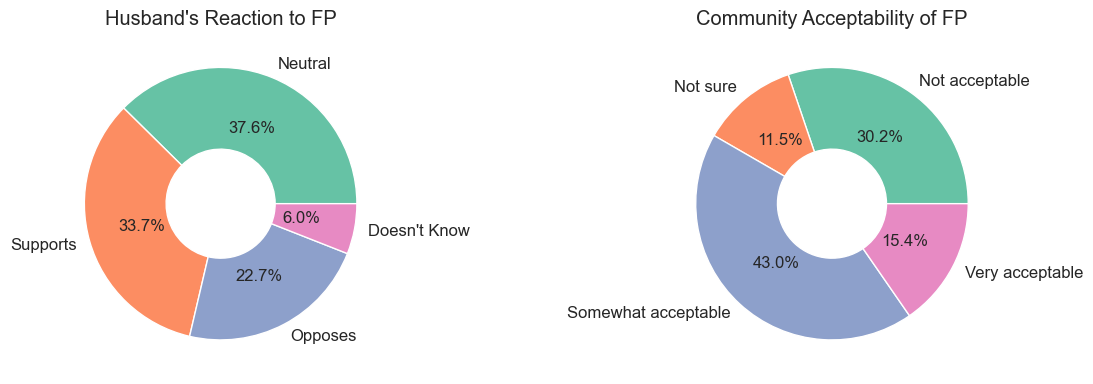

Spousal opposition: 19.8%
Received counseling: 88.0%
Experienced side effects: 25.3%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = sns.color_palette("Set2")

hr_map = {1: "Supports", 2: "Neutral", 3: "Doesn't Know", 4: "Opposes"}
counts = df["husband_reaction_code"].map(hr_map).value_counts()
axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=palette, wedgeprops={"width": 0.6, "edgecolor": "white"})
axes[0].set_title("Husband's Reaction to FP")

ca_order = ["Not acceptable", "Not sure", "Somewhat acceptable", "Very acceptable"]
counts = df["community_acceptability"].value_counts().reindex(ca_order).dropna()
axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=palette, wedgeprops={"width": 0.6, "edgecolor": "white"})
axes[1].set_title("Community Acceptability of FP")

plt.tight_layout()
plt.show()

print(f"Spousal opposition: {(df['husband_reaction_code']==4).mean()*100:.1f}%")
print(f"Received counseling: {df['received_counseling'].mean()*100:.1f}%")
print(f"Experienced side effects: {df['experienced_side_effects'].mean()*100:.1f}%")


## 5. Key Bivariate Associations

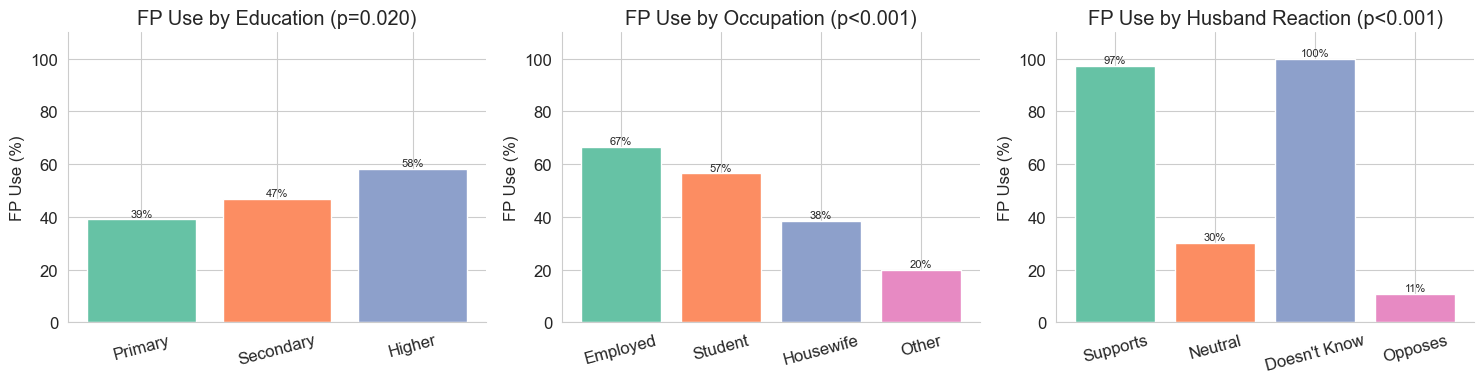

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

comparisons = [
    ("education_code", {1:"None",2:"Primary",3:"Secondary",4:"Higher"},
     ["None","Primary","Secondary","Higher"], "FP Use by Education (p=0.020)"),
    ("occupation", None, ["Employed","Student","Housewife","Other"],
     "FP Use by Occupation (p<0.001)"),
    ("husband_reaction_code", {1:"Supports",2:"Neutral",3:"Doesn't Know",4:"Opposes"},
     ["Supports","Neutral","Doesn't Know","Opposes"], "FP Use by Husband Reaction (p<0.001)"),
]
for ax, (col, label_map, order, title) in zip(axes, comparisons):
    if label_map:
        dep = df.groupby(col)["fp_use"].mean() * 100
        dep.index = dep.index.map(label_map)
    else:
        dep = df.groupby(col)["fp_use"].mean() * 100
    dep = dep.reindex(order).dropna()
    bars = ax.bar(dep.index, dep.values, color=sns.color_palette("Set2")[:len(dep)])
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h+1, f"{h:.0f}%", ha="center", fontsize=8)
    ax.set_ylabel("FP Use (%)")
    ax.set_title(title)
    ax.set_ylim(0, 110)
    ax.tick_params(axis="x", rotation=15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


In [14]:
# Satisfaction vs FP use
r, p = stats.spearmanr(df["satisfaction_code"].dropna(),
                        df.loc[df["satisfaction_code"].notna(), "fp_use"])
print(f"Spearman ρ (satisfaction vs FP use): {r:.3f}, p={p:.4f}")
print(f"Pearson r (satisfaction vs FP use): {df['satisfaction_code'].corr(df['fp_use']):.3f}")

print(f"\nFP use by counseling status:")
print(df.groupby("received_counseling")["fp_use"].mean().rename({0:"No counseling",1:"Counseled"}) * 100)


Spearman ρ (satisfaction vs FP use): nan, p=nan
Pearson r (satisfaction vs FP use): 0.346

FP use by counseling status:
received_counseling
No counseling    18.181818
Counseled        49.700599
Name: fp_use, dtype: float64


## Summary of EDA Findings

| Finding | Value |
|---------|-------|
| Sample size | N = 384 |
| Mean age | 27.53 ± 7.01 years |
| FP use prevalence | 45.3% (n=174) |
| Most common method | Pills (32.2%), Injectables (29.9%) |
| Husband supports FP | 29.4% |
| Husband opposes FP | 19.8% |
| Community: not acceptable | 30.2% |
| Received counseling | 88.0% |
| Experienced side effects | 25.3% |
| Satisfaction (satisfied/very satisfied) | 62.2% |
| Main encouragement factor | Work obligations (72.9%), Health worker advice (71.9%) |
| Top avoidance reason | Desire for more children (27.1%) |
| Strongest bivariate predictor | Husband reaction (χ²=234.077, V=0.781) |
| Spearman ρ (satisfaction vs FP use) | 0.330 (p<0.001) |

Qualitative thematic analysis of 4 open-ended questions documented in `6_docs/qualitative_analysis.md`.
Formal bivariate and multivariate analysis conducted in SPSS (see `4_analysis/full_analysis.sps`).
